# A first LaDyS experiment

Fit GPFA to a small synthetic Lorenz dataset, then inspect the learning curves
and reconstructed neural activity.

Open this notebook in Jupyter with LaDyS, NumPy, and Matplotlib installed in the
kernel's Python environment. Run the cells in order. Everything runs on CPU,
and no data download is needed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ladys import Experiment, ExperimentConfig, PreprocessingConfig
from ladys.datasets import LorenzDatasetConfig
from ladys.models import GPFAConfig
from ladys.training import TrainerConfig

## Configure the experiment

Lorenz dynamics generate firing rates for 12 simulated neurons; Poisson sampling
turns those rates into spike counts. Training and validation use separate trials
of the same underlying trajectories.

`ExperimentConfig` combines the dataset, model, preprocessing, and training
settings. Here we use raw spike counts and a model with three latent dimensions.
The seed fixes the generated data and the training randomness.

In [2]:
config = ExperimentConfig(
    dataset=LorenzDatasetConfig(
        neurons=12,
        num_inits=2,
        num_trials=8,
        num_steps=60,
        seed=0,
    ),
    model=GPFAConfig(latent_dim=3),
    preprocessing=PreprocessingConfig(),
    trainer=TrainerConfig(epochs=20, device="cpu"),
    batch_size=4,
    output_dir="runs/lorenz_tutorial",
)

## Train and evaluate

`Experiment.run()` prepares the data, builds and trains the model, evaluates it
on validation trials, and saves the run. The returned result contains the
learning history, evaluation metrics, and artifact paths.

In [3]:
result = Experiment(config).run()

epoch=1 train_loss=25.7521 valid_loss=23.75


epoch=2 train_loss=24.8226 valid_loss=22.9252


epoch=3 train_loss=23.9475 valid_loss=22.1338


epoch=4 train_loss=23.1278 valid_loss=21.3594


epoch=5 train_loss=22.3165 valid_loss=20.6126


...

epoch=16 train_loss=15.4067 valid_loss=14.305


epoch=17 train_loss=14.951 valid_loss=13.8893


epoch=18 train_loss=14.5199 valid_loss=13.4942


epoch=19 train_loss=14.103 valid_loss=13.121


epoch=20 train_loss=13.732 valid_loss=12.7591


## Plot learning curves

GPFA minimizes negative log marginal likelihood. Lower loss is better; the
validation curve shows how the model fits trials it did not train on.

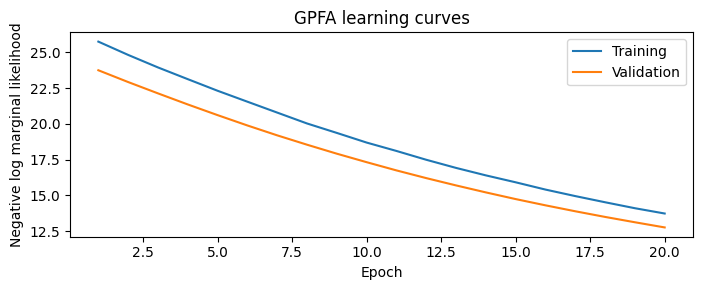

In [4]:
epochs = [report.epoch + 1 for report in result.history]
train_loss = [report.train.loss for report in result.history]
valid_loss = [report.valid.loss for report in result.history]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(epochs, train_loss, label="Training")
ax.plot(epochs, valid_loss, label="Validation")
ax.set(xlabel="Epoch", ylabel="Negative log marginal likelihood", title="GPFA learning curves")
ax.legend()
fig.tight_layout()
plt.show()

## Inspect reconstructed activity

The saved predictions contain the model's estimated rates and the known Lorenz
rates for the validation trials. Compare them for one neuron in the first
validation trial. Ground-truth rates are used for evaluation, not training.

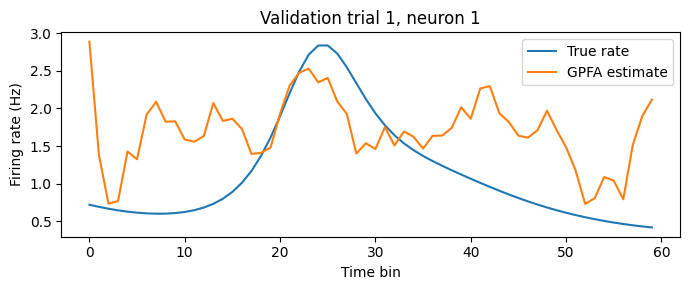

In [5]:
with np.load(result.predictions_path) as predictions:
    true_rates = predictions["target_rates"][0, :, 0]
    predicted_rates = predictions["pred_rates"][0, :, 0]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(true_rates, label="True rate")
ax.plot(predicted_rates, label="GPFA estimate")
ax.set(xlabel="Time bin", ylabel="Firing rate (Hz)", title="Validation trial 1, neuron 1")
ax.legend()
fig.tight_layout()
plt.show()

## Inspect the results

The run folder includes `config.json`, `history.csv`, `metrics.json`,
`model.pt`, and `predictions.npz`. The metrics below include rate reconstruction
error and latent reconstruction quality.

In [6]:
print(f"Run saved to: {result.run_dir}")
result.metrics

Run saved to: runs/lorenz_tutorial/20260913_135654_484668_lorenz_gpfa


{'co_bps': 0.030494587495923042,
 'poisson_nll': -0.014043680392205715,
 'rate_mse': 34.32365036010742,
 'rate_r2': 0.03222060203552246,
 'latent_linear_r2': 0.3593559342170677}

Try changing `latent_dim` or `epochs` and rerun from the configuration cell.
For other models and configuration options, see the
[LaDyS documentation](https://zkunkworks.com/ladys/).